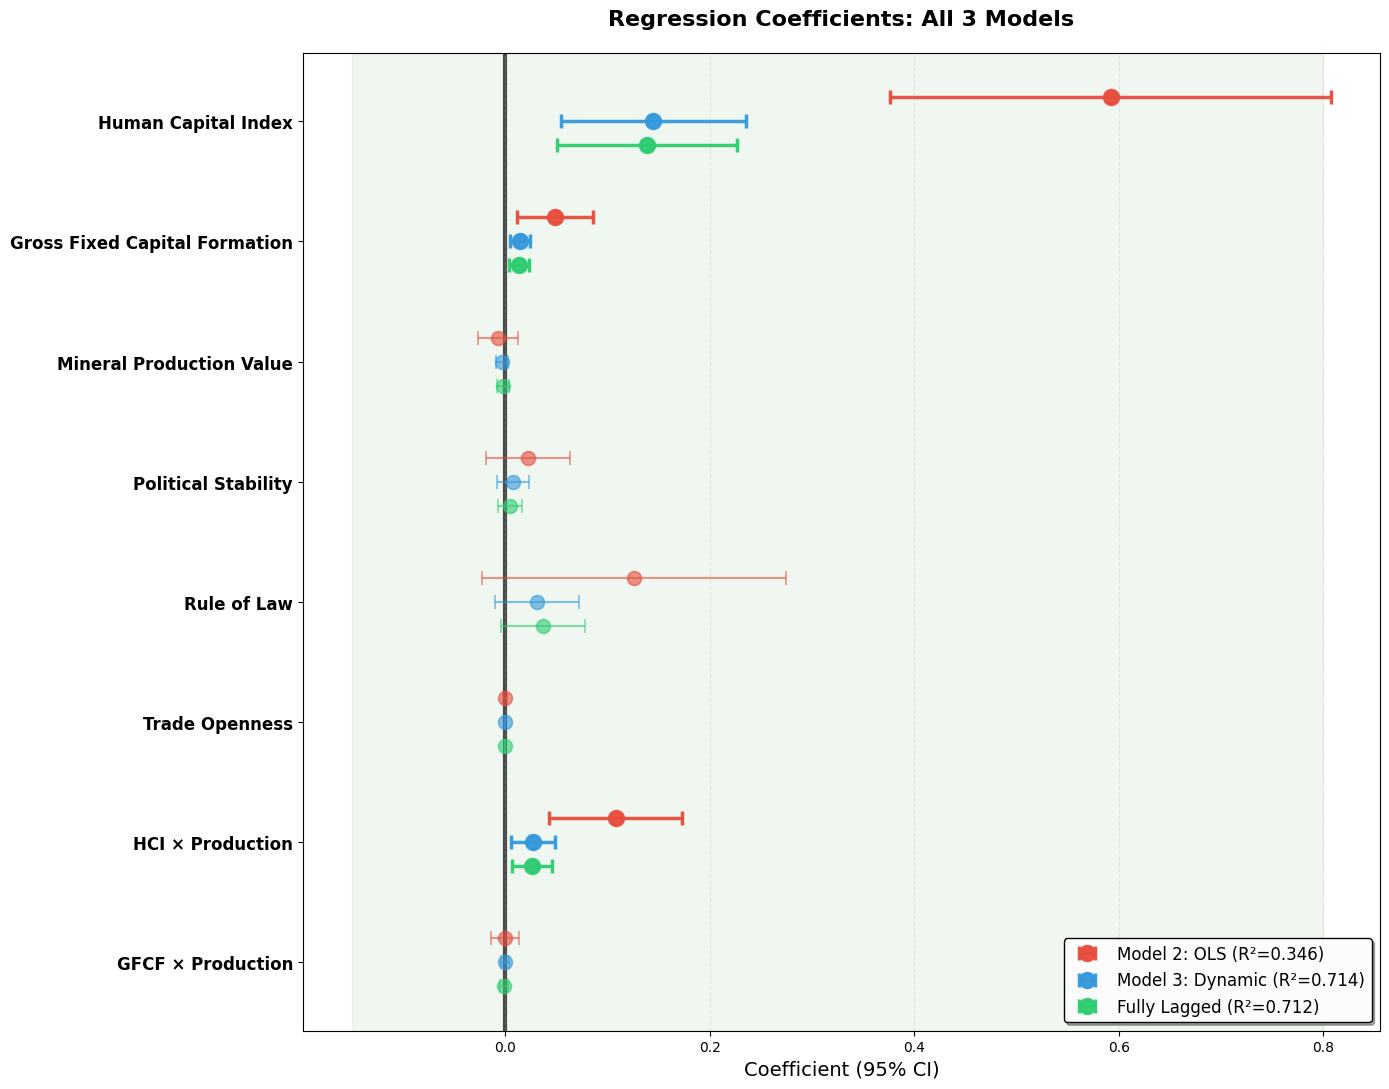

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px

# All three models data
data = {
    'Feature': [
        'Human Capital Index',
        'Gross Fixed Capital Formation',
        'Mineral Production Value',
        'Political Stability',
        'Rule of Law',
        'Trade Openness',
        'HCI × Production',
        'GFCF × Production'
    ],
    # Model 2: OLS
    'M2_Coef': [0.592, 0.049, -0.007, 0.022, 0.126, -0.000, 0.108, 0.000],
    'M2_SE': [0.110, 0.019, 0.010, 0.021, 0.076, 0.001, 0.033, 0.007],
    'M2_Sig': ['***', '**', '', '', '*', '', '***', ''],
    # Model 3: Dynamic Panel
    'M3_Coef': [0.145, 0.015, -0.003, 0.008, 0.031, -0.000, 0.027, -0.000],
    'M3_SE': [0.046, 0.005, 0.003, 0.008, 0.021, 0.000, 0.011, 0.002],
    'M3_Sig': ['***', '***', '', '', '', '', '**', ''],
    # Fully Lagged Model
    'ML_Coef': [0.139, 0.014, -0.002, 0.005, 0.037, 0.000, 0.026, -0.001],
    'ML_SE': [0.045, 0.005, 0.003, 0.006, 0.021, 0.000, 0.010, 0.002],
    'ML_Sig': ['***', '***', '', '', '*', '', '**', '']
}

df = pd.DataFrame(data)

# Calculate 95% CI for all models
for model in ['M2', 'M3', 'ML']:
    df[f'{model}_Lower'] = df[f'{model}_Coef'] - 1.96 * df[f'{model}_SE']
    df[f'{model}_Upper'] = df[f'{model}_Coef'] + 1.96 * df[f'{model}_SE']

# ============================================================================
# MAIN PLOT: All 3 Models Overlaid
# ============================================================================

fig, ax = plt.subplots(figsize=(14, 11))

y_pos = np.arange(len(df))
offset = 0.2


# Model colors
model_colors = {
    'M2': '#E74C3C',      # Red
    'M3': '#3498DB',      # Blue  
    'ML': '#2ECC71'       # Green
}

model_markers = {
    'M2': 'o',
    'M3': 'o',
    'ML': 'o'
}

model_labels = {
    'M2': 'Model 2: OLS (R²=0.346)',
    'M3': 'Model 3: Dynamic (R²=0.714)',
    'ML': 'Fully Lagged (R²=0.712)'
}

# Plot each model
for model_idx, model in enumerate(['M2', 'M3', 'ML']):
    y_offset = (model_idx - 1) * offset
    
    for i, (_, row) in enumerate(df.iterrows()):
        if not pd.isna(row[f'{model}_Coef']):
            color = model_colors[model]
            marker = model_markers[model]
            
            # Check 5% significance
            is_sig_5 = row[f'{model}_Sig'] in ['**', '***']
            
            # Same size for all, but different alpha/edge for significance
            size = 150 if row[f'{model}_Sig'] in ['**', '***'] else 100
            edge_width = 2.5 if is_sig_5 else 1.2
            alpha_val = 0.95 if is_sig_5 else 0.6
            
            # Plot point
            ax.errorbar(row[f'{model}_Coef'], i + y_offset,
                       xerr=[[row[f'{model}_Coef'] - row[f'{model}_Lower']], 
                             [row[f'{model}_Upper'] - row[f'{model}_Coef']]],
                       fmt=marker, markersize=10, color=color,
                       ecolor=color, elinewidth=2.5 if is_sig_5 else 1.5, 
                       capsize=5, alpha=alpha_val, markeredgewidth=edge_width,
                       label=model_labels[model] if i == 0 else '', zorder=3)
            
# Zero line
ax.axvline(0, color='black', linewidth=3, linestyle='-', alpha=0.7, zorder=1)

# Background shading

ax.axvspan(-0.15, 0.8, alpha=0.06, color='green', zorder=0)

ax.set_yticks(y_pos)
ax.set_yticklabels(df['Feature'], fontsize=12, fontweight='bold')
ax.set_xlabel('Coefficient (95% CI)', fontsize=14)
ax.set_title('Regression Coefficients: All 3 Models', 
            fontsize=16, fontweight='bold', pad=20)
ax.invert_yaxis()
ax.legend(fontsize=12, loc='lower right', framealpha=0.98, 
         edgecolor='black', fancybox=True, shadow=True)
ax.grid(axis='x', alpha=0.25, linestyle='--')

plt.tight_layout()
plt.show()